In [ ]:
!pip install statsmodels

In [ ]:
!pip install wquantiles

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
Jack=pd.read_csv('/content/titanic-train.csv')

In [ ]:
Jack.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
Jack.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
total=Jack.isnull().sum().sort_values(ascending=False)
total

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [ ]:
Jack.isnull().count()

,0
PassengerId,891
Survived,891
Pclass,891
Name,891
Sex,891
Age,891
SibSp,891
Parch,891
Ticket,891
Fare,891


In [ ]:
porcentajes=(Jack.isnull().sum()/Jack.isnull().count()).sort_values(ascending=False)
porcentajes

,0
Cabin,0.771044
Age,0.198653
Embarked,0.002245
PassengerId,0.000000
Name,0.000000
Pclass,0.000000
Survived,0.000000
Sex,0.000000
Parch,0.000000
SibSp,0.000000


In [ ]:
datos_perdidos=pd.concat([total,porcentajes],axis=1,keys=['Total','Porcentaje'])
datos_perdidos

,Total,Porcentaje
Cabin,687,0.771044
Age,177,0.198653
Embarked,2,0.002245
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


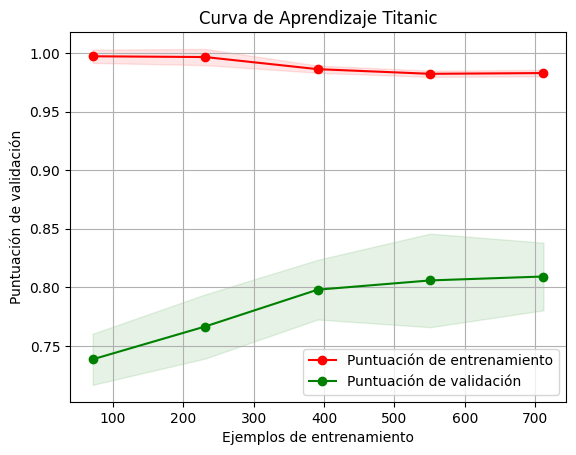

In [ ]:
def plot_learning_curve(estimator, title, X, y, ylim=None, xlim=None, cv=None, n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5)):
    #Crea una nueva figura para la grafica
    plt.figure()
    #Le pone titulo que se pasó como argfumento
    plt.title(title)
    #Establece los límites del eje Y
    if ylim is not None:
        plt.ylim(*ylim)
    #Establece las etiquetas de los ejes
    plt.xlabel("Ejemplos de entrenamiento")
    plt.ylabel("Puntuación de validación")

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)

    #Calcula la media y desviación estándar para cada tamaño de muestra, tanto para entrenamiento como para validación.
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    #Activa la cuadrícula de fondo de la gráfica.
    plt.grid()

    #Colorea una banda roja suave (con alpha=0.1) que muestra la variación (desviación estándar) de los resultados en entrenamiento.
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")

    #Hace lo mismo para los resultados en validación, pero en verde.
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")

    #Dibuja la curva de aprendizaje en entrenamiento (línea roja con círculos).
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Puntuación de entrenamiento")

    #Dibuja la curva de aprendizaje en validación (línea verde con círculos).
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Puntuación de validación")

    #Agrega la leyenda que identifica cada línea (entrenamiento vs validación).
    plt.legend(loc="best")
    return plt

#Llama la función y muestra la gráfica
plot_learning_curve(Jack, "Curva de Aprendizaje Titanic", X, y, cv=5)
plt.show()

**estimator:** el modelo que vamos a entrenar (por ejemplo, un RandomForestClassifier).

**title:** el título de la gráfica.

**X:** las variables independientes (características o atributos).

**y:** la variable objetivo (por ejemplo, si sobrevivió o no).

**ylim (opcional):** límites en el eje Y de la gráfica. Si se pone, se ajusta el rango.

**xlim (opcional):** límites en el eje X (aunque no se usa en el cuerpo de la función).

**cv:** número de particiones para validación cruzada (cv=5 significa 5 particiones).

**n_jobs:** número de núcleos de CPU a usar. n_jobs=1 usa solo uno; -1 usa todos.

**train_sizes:** proporciones del conjunto de entrenamiento que se usan (desde el 10% hasta el 100%, en 5 pasos).

Usa la función learning_curve de scikit-learn para:

* Entrenar el modelo varias veces con diferentes cantidades de datos.

* Obtener accuracy (o puntuación) de entrenamiento y validación en cada caso.

Devuelve:

* **train_sizes:** cantidades de datos usadas en cada paso.

* **train_scores:** resultados en entrenamiento.

* **test_scores:** resultados en validación (con cv).

## Explicación de la gráfica

Esta gráfica muestra cómo el modelo va aprendiendo a medida que le damos más ejemplos. La línea roja representa qué tan bien le va con los datos que ya conoce (entrenamiento), y se mantiene muy alta todo el tiempo. Eso significa que el modelo aprende muy bien lo que se le da. Por otro lado, la línea verde muestra qué tan bien le va con datos nuevos que no ha visto antes (validación). Al principio le cuesta, pero a medida que le damos más datos, va mejorando su rendimiento. Aunque hay una diferencia entre las dos líneas, lo importante es que la verde va subiendo y se va estabilizando, lo que quiere decir que el modelo está aprendiendo mejor con el tiempo. Las sombritas que se ven indican que a veces los resultados cambian un poco según los datos, pero en general se comporta de forma estable.